In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('../data/mixed_augment/labels.tsv', sep='\t')
df

,Unnamed: 0,dataset,spec,ionization,formula,smiles,inchikey,instrument
0,0,mixed_augment_neims,mix_aug_0,[M]+,C8H11NO2,Cc1nc(O)c(C)c(O)c1C,DGFZETPZVVBGDX-UHFFFAOYSA-N,simulated
1,1,mixed_augment_neims,mix_aug_1,[M]+,C9H13NO2,CCCn1c(C)cc(O)cc1=O,PVPCCBVPEPJYMT-UHFFFAOYSA-N,simulated
2,2,mixed_augment_neims,mix_aug_2,[M]+,C9H11NO3,COC(=O)c1ccc(C)n(C)c1=O,VZNOBKUONZMASH-UHFFFAOYSA-N,simulated
3,3,mixed_augment_neims,mix_aug_3,[M]+,C9H10NO3-,CC(=O)c1c([O-])n(C)c(C)cc1=O,FTVRPCGIXCTJFH-UHFFFAOYSA-M,simulated
4,4,mixed_augment_neims,mix_aug_4,[M]+,C8H11NO2,CCOc1cc[n+]([O-])c(C)c1,FLJUUOITHXOKDV-UHFFFAOYSA-N,simulated
...,...,...,...,...,...,...,...,...
291060,291060,mixed_augment_neims,mix_aug_291060,[M]+,C28H19F42N2O8PS2,CCN(CCOP(=O)(O)OCCN(CC)S(=O)(=O)C(F)(F)C(F)(F)...,PKNXYWCLSVQSFV-UHFFFAOYSA-N,simulated
291061,291061,mixed_augment_neims,mix_aug_291061,[M]+,C34H40I6N4O12,CC(=O)N(C)c1c(I)c(C(=O)O)c(I)c(N(CC(O)COCCCCOC...,PTZLONROPJVDRQ-UHFFFAOYSA-N,simulated
291062,291062,mixed_augment_neims,mix_aug_291062,[M]+,C26HF53O8,FC(OC(F)(F)C(F)(OC(F)(F)C(F)(OC(F)(F)C(F)(OC(F...,SIEUTGCQJFIIPL-UHFFFAOYSA-N,simulated
291063,291063,mixed_augment_neims,mix_aug_291063,[M]+,C34H40I6N4O11,CCCC(O)=NCc1c(I)c(N=C(O)CCOCCOCCOCCC(O)=Nc2c(I...,IUBZUALWPQQYOQ-UHFFFAOYSA-N,simulated


In [6]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt

def heavy_atom_count(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return mol.GetNumHeavyAtoms()

df['heavy_atoms'] = df['smiles'].map(heavy_atom_count)
invalid = df['heavy_atoms'].isna().sum()
print(f"Invalid SMILES: {invalid} / {len(df)}")
df['heavy_atoms'].describe()

Invalid SMILES: 0 / 291065


count    291065.000000
mean         28.272121
std          12.735741
min           3.000000
25%          19.000000
50%          25.000000
75%          38.000000
max          91.000000
Name: heavy_atoms, dtype: float64

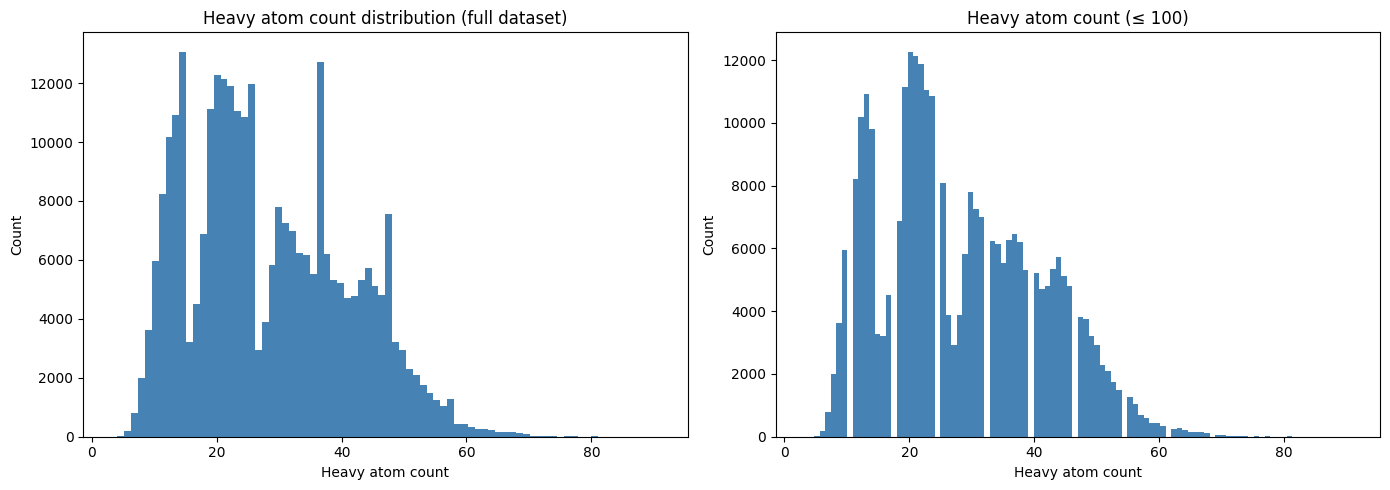

Percentiles:
    1th: 8
    5th: 11
   10th: 12
   25th: 19
   50th: 25
   75th: 38
   90th: 46
   95th: 50
   99th: 58
  100th: 91


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df['heavy_atoms'].dropna(), bins=80, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Heavy atom count')
axes[0].set_ylabel('Count')
axes[0].set_title('Heavy atom count distribution (full dataset)')

# Zoomed: 0–100 to see the bulk
df_clipped = df['heavy_atoms'].dropna()
axes[1].hist(df_clipped[df_clipped <= 100], bins=100, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Heavy atom count')
axes[1].set_ylabel('Count')
axes[1].set_title('Heavy atom count (≤ 100)')

plt.tight_layout()
plt.show()

# Percentile breakdown
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
print("Percentiles:")
for p in pcts:
    print(f"  {p:>3}th: {df['heavy_atoms'].quantile(p/100):.0f}")

In [8]:
thresholds = [50, 75, 100, 125, 150]
total = df['heavy_atoms'].notna().sum()
print(f"{'Cap':>5}  {'Retained':>10}  {'Dropped':>10}  {'Retained %':>11}")
print("-" * 42)
for t in thresholds:
    kept = (df['heavy_atoms'] <= t).sum()
    dropped = total - kept
    print(f"{t:>5}  {kept:>10,}  {dropped:>10,}  {100*kept/total:>10.2f}%")

print(f"\nMax heavy atoms in dataset: {int(df['heavy_atoms'].max())}")
print(f"model node_counts default cap: 150")

  Cap    Retained     Dropped   Retained %
------------------------------------------
   50     277,054      14,011       95.19%
   75     290,991          74       99.97%
  100     291,065           0      100.00%
  125     291,065           0      100.00%
  150     291,065           0      100.00%

Max heavy atoms in dataset: 91
model node_counts default cap: 150
